# <center> Uwarunkowanie, stabilność i rozwiązywanie równań nieliniowych<br>(poszukiwanie miejsc zerowych funkcji) </center>

# Uwarunkowanie i stabilność


***Zadanie 1. Czy wyznaczanie miejsc zerowych wielomianu może być zadaniem dobrze/źle uwarunkowanym? (Wielomian Wilkinsona)***

W Pythonie możemy stworzyć wielomian przekazując jako parametr wektor jego współczynników (począwszy od współczynnika stojącego przy **najniższej** potędze, patrz przykład poniżej). Proszę korzystać z modułu *numpy.polynomial* (zamiast *poly1d*).
* Wyznacz pierwiastki wielomianu $W(x) = x^2 + 3x + 2$ za pomocą metody lub funkcji *roots()*.
* Funkcja *Polynomial.fromroots* tworzy wielomian na podstawie listy przekazanych pierwiastków. Utwórz wielomian o następujących pierwiastkach $\{x_n = n, n = 1, 2, 3, . . . , 15\}$.
* Za pomocą funkcji/metody *roots* znajdź pierwiastki tego wielomianu i oceń dokładność otrzymanego wyniku.
* Do trzynastego elementu wektora współczynników wprowadź małe zaburzenie (np. rzędu $10^−5$) i znajdź pierwiastki wielomianu o zaburzonych współczynnikach. Wykreśl pierwiastki na płaszczyznie zespolonej. 
* Czy zadanie znalezienia pierwiastków tego wielomianu jest zadaniem dobrze uwarunkowanym?


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from numpy.polynomial import Polynomial
# Przykłady operacji na wielomianach
p = Polynomial([3, 2, 1]) # Od ostatniego współczynnika
print(p)
print(p.roots())
print(Polynomial.roots(p))




Pierwiastki x^2 + 3x + 2: [-2. -1.]
Maksymalny błąd bez zaburzenia: 8.00e-06


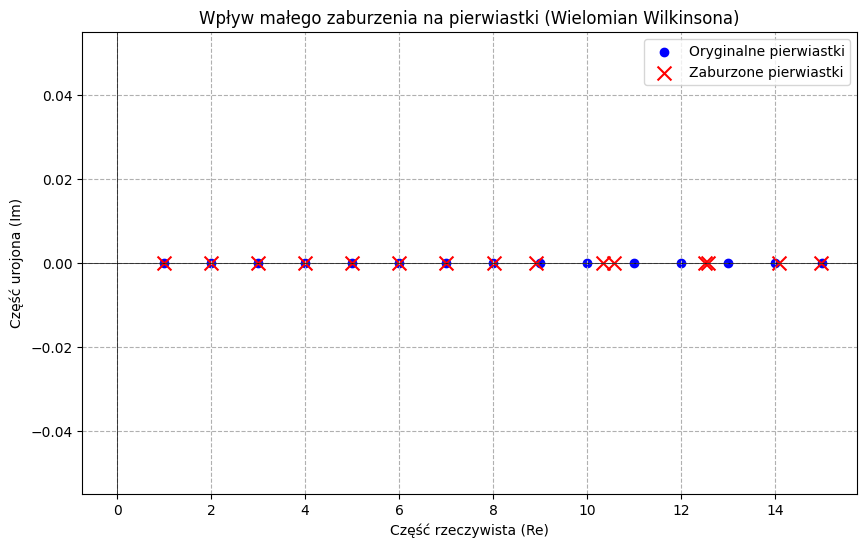

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial

# 1. Wielomian W(x) = x^2 + 3x + 2
# Moduł Polynomial przyjmuje współczynniki od najniższej potęgi: [a_0, a_1, a_2]
w1 = Polynomial([2, 3, 1])
print("Pierwiastki x^2 + 3x + 2:", w1.roots())

# 2. Utworzenie wielomianu o pierwiastkach 1..15
dokladne_pierwiastki = np.arange(1, 16)
w2 = Polynomial.fromroots(dokladne_pierwiastki)

# 3. Wyznaczenie pierwiastków i ocena dokładności
obliczone_pierwiastki = w2.roots()
blad_maksymalny = np.max(np.abs(np.sort(dokladne_pierwiastki) - np.sort(obliczone_pierwiastki)))
print(f"Maksymalny błąd bez zaburzenia: {blad_maksymalny:.2e}")

# 4. Wprowadzenie zaburzenia (np. do 13. elementu, czyli indeks 12)
zaburzone_wspolczynniki = w2.coef.copy()
zaburzone_wspolczynniki[12] += 1e-5
w3 = Polynomial(zaburzone_wspolczynniki)
zaburzone_pierwiastki = w3.roots()

# 5. Wykres na płaszczyźnie zespolonej
plt.figure(figsize=(10, 6))
plt.scatter(np.real(obliczone_pierwiastki), np.imag(obliczone_pierwiastki), 
            color='blue', marker='o', label='Oryginalne pierwiastki')
plt.scatter(np.real(zaburzone_pierwiastki), np.imag(zaburzone_pierwiastki), 
            color='red', marker='x', s=100, label='Zaburzone pierwiastki')

plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)
plt.xlabel('Część rzeczywista (Re)')
plt.ylabel('Część urojona (Im)')
plt.title('Wpływ małego zaburzenia na pierwiastki (Wielomian Wilkinsona)')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

***Zadanie 2. Całka oznaczona***

Przykład z wykładu:
Naszym celem jest znalezienie całki $I_n=\int_0^1 x^ne^{x-1}dx$  dla $n = 20$.
* Na podstawie np. przybliżonych wykresów funkcji podcałkowej, proszę oszacować wartość tej całki oraz relację miedzy $I_n$ a $I_{n−1}$.
* Ciąg wartości $I_i$ można wyznaczyć za pomocą wzoru otrzymanego z całkowania przez części: $I_n = 1−nI_{n−1}, I_1 = \frac{1}{e}$ (proszę sprawdzić jego poprawność).
* Czy otrzymane wyniki są zgodne z przewidywaniami? Która operacja może powodować takie skutki?
* Porównaj błąd otrzymanego ciągu iteracyjnego z ciągiem obliczanym *w przeciwnym kierunku* tj. od $I_{20}$ do $I_1$. Proszę przyjąć, że $I_{20} = 0$.
* Jak duży jest błąd danej wejściowej ($I_{20}$) i ostatniego elementu ciągu ($I_1$)?
* Który algorytm jest stabilny, a który niestabilny?

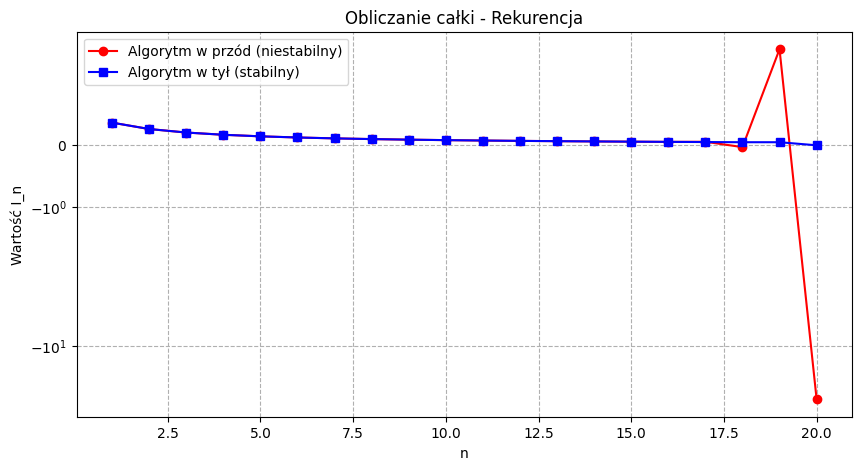

I_1 obliczone w tył: 0.367879 (Oczekiwane ok. 0.367879)


In [2]:
n_max = 20

# 1. Kierunek "w przód" (od I_1 do I_20)
I_przod = np.zeros(n_max + 1)
I_przod[1] = 1 / np.e

for n in range(2, n_max + 1):
    I_przod[n] = 1 - n * I_przod[n-1]

# 2. Kierunek "w tył" (od I_20 do I_1)
I_tyl = np.zeros(n_max + 1)
I_tyl[20] = 0 # Przyjmujemy zgrubne założenie

for n in range(20, 1, -1):
    I_tyl[n-1] = (1 - I_tyl[n]) / n

# 3. Wizualizacja i porównanie
plt.figure(figsize=(10, 5))
plt.plot(range(1, 21), I_przod[1:], 'r-o', label='Algorytm w przód (niestabilny)')
plt.plot(range(1, 21), I_tyl[1:], 'b-s', label='Algorytm w tył (stabilny)')
plt.yscale('symlog') # Skala logarytmiczna z obsługą wartości ujemnych
plt.xlabel('n')
plt.ylabel('Wartość I_n')
plt.title('Obliczanie całki - Rekurencja')
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

print(f"I_1 obliczone w tył: {I_tyl[1]:.6f} (Oczekiwane ok. {1/np.e:.6f})")

# Poszukiwanie miejsc zerowych

Dana jest funkcja $$f(x) = e^{-2x}+x^2-1$$

***Zadanie 1.***

Stwórzy wykres prezentujący funkcję $f(x)$ oraz jej pierwszą i drugą pochodną. Na podstawie spróbuj oszacować wartości pierwiastków równania $f(x) = 0$.

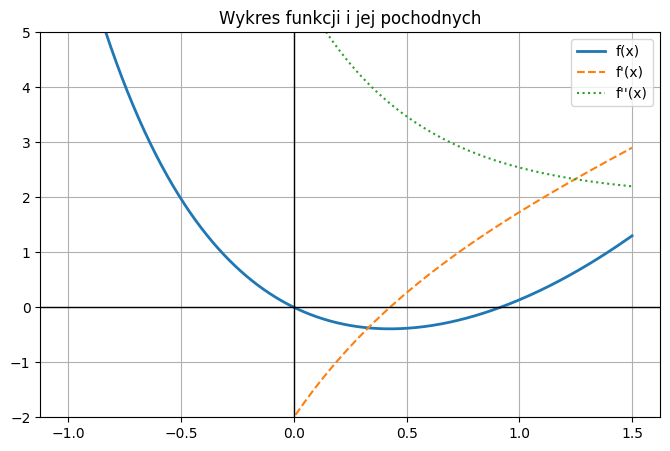

In [3]:
f = lambda x: np.exp(-2*x) + x**2 - 1
df = lambda x: -2*np.exp(-2*x) + 2*x
ddf = lambda x: 4*np.exp(-2*x) + 2

x_vals = np.linspace(-1, 1.5, 400)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, f(x_vals), label='f(x)', linewidth=2)
plt.plot(x_vals, df(x_vals), label="f'(x)", linestyle='--')
plt.plot(x_vals, ddf(x_vals), label="f''(x)", linestyle=':')
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.ylim(-2, 5)
plt.title("Wykres funkcji i jej pochodnych")
plt.legend()
plt.grid()
plt.show()

***Zadanie 2.***

Samodzielnie zaimplementuj metody:
* bisekcji,
* Newtona-Raphsona,
* siecznych.

Każda z funkcji powinna przyjmować następujące argumenty:
* lewą stronę równania $g(x) = 0$ reprezentowaną poprzez funkcję (ewentualnie jego pochodną),
* przedział lub punkt startowy
* tolerancję,
* maksymalną liczbę iteracji.

i zwracać:
* znaleziony pierwiastek,
* liczbę iteracji.

W jaki sposób sprawdzić warunek stopu? Czy kryterium stopu polegające na kontynuacji iteracji dopóki $x_{i+1}\neq x_i$ jest prawidłowe (bezpieczne)?

In [4]:
def bisekcja(f, a, b, tol, max_iter=100):
    if f(a) * f(b) >= 0:
        raise ValueError("Funkcja musi mieć różne znaki na krańcach przedziału!")
    
    historia = []
    for i in range(max_iter):
        c = (a + b) / 2
        historia.append(c)
        if abs(f(c)) < tol or (b - a) / 2 < tol:
            return c, i + 1, historia
            
        if f(a) * f(c) < 0:
            b = c
        else:
            a = c
    return c, max_iter, historia

def newton_raphson(f, df, x0, tol, max_iter=100):
    x = x0
    historia = [x]
    for i in range(max_iter):
        if abs(df(x)) < 1e-12: # Zabezpieczenie przed dzieleniem przez zero
            break
        x_new = x - f(x) / df(x)
        historia.append(x_new)
        if abs(x_new - x) < tol or abs(f(x_new)) < tol:
            return x_new, i + 1, historia
        x = x_new
    return x, max_iter, historia

def siecznych(f, x0, x1, tol, max_iter=100):
    historia = [x0, x1]
    for i in range(max_iter):
        if abs(f(x1) - f(x0)) < 1e-12: # Zabezpieczenie
            break
        x_new = x1 - f(x1) * (x1 - x0) / (f(x1) - f(x0))
        historia.append(x_new)
        if abs(x_new - x1) < tol or abs(f(x_new)) < tol:
            return x_new, i + 1, historia
        x0, x1 = x1, x_new
    return x_new, max_iter, historia

***Zadanie 3.***

Wykorzystaj stworzone w zadaniu 2. metody do znalezienia miejsc zerowych funkcji $f(x)$ z dokładnością $\epsilon = 10^{-6}$. Porównaj liczby iteracji niezbędnych do znalezienia pierwiastka. Która metoda sprawdziła się najlepiej? Która wypada najgorzej? Czy odpowiedni dobór przedziału może przyspieszyć proces rozwiązywania? Eksperyment przeprowadź dla wszystkich miejsc zerowych $f(x)$.


Newton-Raphson sprawdza się najlepiej, ponieważ potrzebuje najmniej iteracji, ale wymaga znajomości analitycznej postaci pochodnej. Charakteryzuje się bardzo gwałtownym spadkiem błędu przy końcowych iteracjach (wykres logarytmiczny spada błyskawicznie – to tzw. zbieżność kwadratowa).Bisekcja wypada najgorzej pod kątem liczby iteracji. Jej błąd maleje liniowo, lecz jest najbezpieczniejszą metodą (o ile poprawnie otoczymy pierwiastek). Zwężenie przedziału poszukiwań startowych przyspieszyłoby działanie.Metoda siecznych to doskonały kompromis: jest niemal tak szybka jak Newton (zbieżność potęgowa z wykładnikiem rzędu $\approx 1.618$), ale nie potrzebuje dostarczania wzoru na pochodną z zewnątrz.

***Zadanie 4.***

Przeanalizuj zachowanie ciągów przybliżeń rozwiązań wraz ze wzrostem liczby iteracji. Przedstaw wyniki w postaci wykresu i dokonaj ich analizy.

Bisekcja: root = 0.916562, iteracje = 20
Newton:   root = 0.916563, iteracje = 4
Sieczne:  root = 0.916563,  iteracje = 5


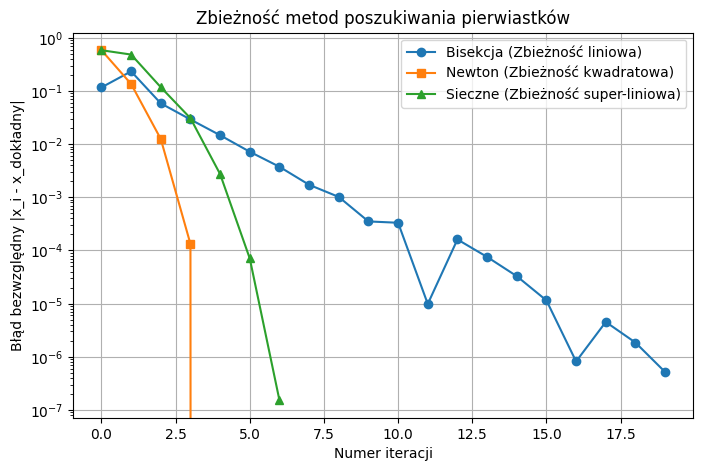

In [6]:
tol = 1e-6

# Bisekcja (dla pierwiastka > 0 potrzebujemy izolacji: omijamy zero, zaczynamy od 0.1)
root_bis, iter_bis, hist_bis = bisekcja(f, 0.1, 1.5, tol)

# Newton-Raphson
root_newt, iter_newt, hist_newt = newton_raphson(f, df, 1.5, tol)

# Sieczne
root_sec, iter_sec, hist_sec = siecznych(f, 1.5, 1.4, tol)

print(f"Bisekcja: root = {root_bis:.6f}, iteracje = {iter_bis}")
print(f"Newton:   root = {root_newt:.6f}, iteracje = {iter_newt}")
print(f"Sieczne:  root = {root_sec:.6f},  iteracje = {iter_sec}")

# WIZUALIZACJA ZBIEŻNOŚCI (Zadanie 4)
# Wyliczamy błąd w odniesieniu do wartości uzyskanej z najdokładniejszej metody
dokladny_root = root_newt 

plt.figure(figsize=(8, 5))
plt.plot(np.abs(np.array(hist_bis) - dokladny_root), 'o-', label='Bisekcja (Zbieżność liniowa)')
plt.plot(np.abs(np.array(hist_newt) - dokladny_root), 's-', label='Newton (Zbieżność kwadratowa)')
plt.plot(np.abs(np.array(hist_sec) - dokladny_root), '^-', label='Sieczne (Zbieżność super-liniowa)')

plt.yscale('log')
plt.xlabel('Numer iteracji')
plt.ylabel('Błąd bezwzględny |x_i - x_dokładny|')
plt.title('Zbieżność metod poszukiwania pierwiastków')
plt.legend()
plt.grid(True)
plt.show()